In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Cyclistic Bike-share Analysis****

Ask:
Business Task: How do annual members and casual riders use Cyclistic bikes differently?

Stakeholders: Cyclistic's manager, assistant manager, marketing department, and project manager.

Business Objective: Design marketing strategies aimed at converting casual riders into annual members.

Prepare:
The data has been made available by Motivate International Inc.
Each zip file contains one month of Cyclistic travel data. I will use the data for the first three months of 2025 for analysis.
The data is officially provided by Google and is the original record from this virtual company. The data includes user travel data for each month in the first three months of 2025. I will combine the data for these three months for analysis. And the database has been updated every month so far, with Google providing the data source.
Google uses it in the course and provides a download link to the dataset. All data only contains ride-id, and personal privacy data such as name, phone number, bank card, etc. are not explicitly given. After the data set is downloaded by me, I will copy the backup of the data on my computer and use the copy of the data for processing and analysis to ensure data security. The data can be viewed after being downloaded and decompressed, and can be opened and processed in an Excel spreadsheet.

Process:
First, after I downloaded all the data for the three months of 2025, I checked the column names and data types of each data set to ensure that the three-month data sets could be merged smoothly.
I merged the data for 3 months in 2025 through VS Code and stored the merged data in the output folder.
After merging 3 months of data, I started to check the data and delete duplicates and invalid values.
No duplicate records were found.
There are no blank spaces.
I created two new columns, ride_length and day_of_week, and found that a lot of ride length data was invalid. Among the 588724 pieces of data, a total of 1048 pieces of ride_length data are 0 or negative, which accounts for 0.18%. Although the proportion of invalid data is very small, I noticed that most of the invalid data comes from members.
I cleaned all data rows with ride_length less than or equal to 0, and the data cleaning was completed.

In [1]:
import pandas as pd
import glob
import os

# Find all CSV files in the data folder
files = glob.glob("/kaggle/input/datasets/kaniayu/raw-data/*.csv")

# Check how many files were found
print(f"found {len(files)} CSV files")

# Read all CSV
df_list = []

for file in files:
    print("Reading：", os.path.basename(file))
    df = pd.read_csv(file)
    df_list.append(df)

# Merge data
combined_df = pd.concat(df_list, ignore_index=True)

# Results
print("\nMerge complete.")
print(combined_df.shape)

# Save to output folder
combined_df.to_csv("/kaggle/working/combined_2025.csv", index=False)

print("combined_2025.csv saved!")

found 3 CSV files
Reading： 202502-divvy-tripdata.csv
Reading： 202503-divvy-tripdata.csv
Reading： 202501-divvy-tripdata.csv

Merge complete.
(588724, 13)
combined_2025.csv saved!


Analyze:
By analyzing the data, I found that the average ride length in the data is 7 minutes and 33 seconds, the longest ride length is 2 hours and 28 minutes, and the day when the most users use shared bicycles is Friday.
In the new worksheet, I used pivot table to analyze the ride_length and ride_id of casual and member respectively.
The data shows that the number of casual rides is much less than that of members, and the average ride time of casual users is longer than the average ride length of members. When I put day_of_week into the pivot table, I found that casual users will increase by about 60% on Friday and Saturday, while the number of member users is the least on Saturday and Sunday. We can preliminarily infer that members have less demand for shared bicycles on weekends, while the demand for shared bicycles is higher during weekdays. For casual users, their demand for shared bicycles is higher on Fridays and Saturdays, while demand is lower from Sunday to Thursday.
For users’ riding habits, I found that member users ride more often, but for shorter rides; while casual users ride less frequently, but ride for longer time.

Share:
I used the pivot table created earlier to generate two charts, namely Average Ride Duration by Day of Week and Ride Frequency by Day of Week.
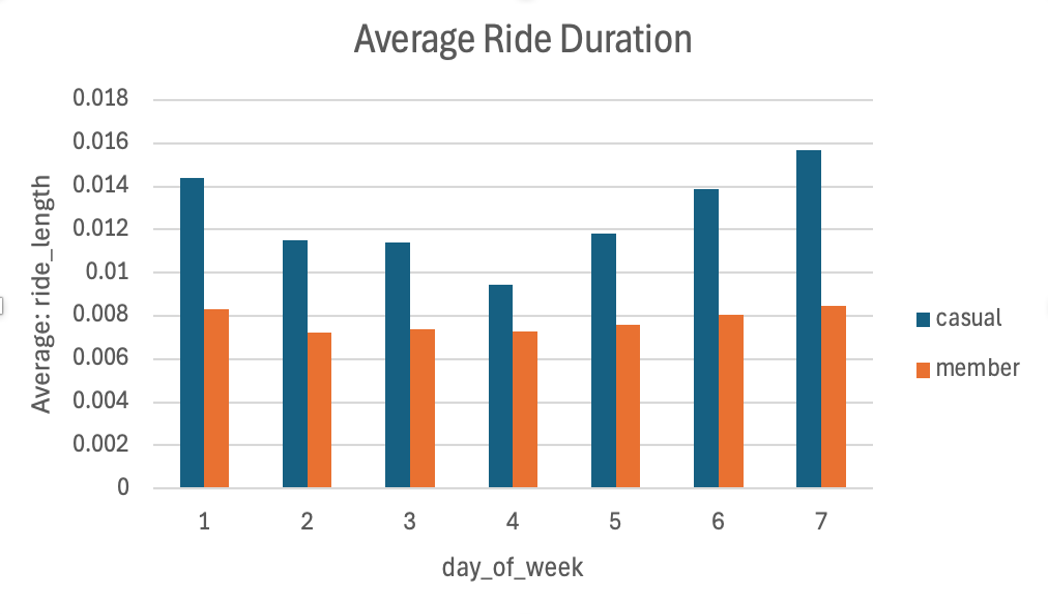
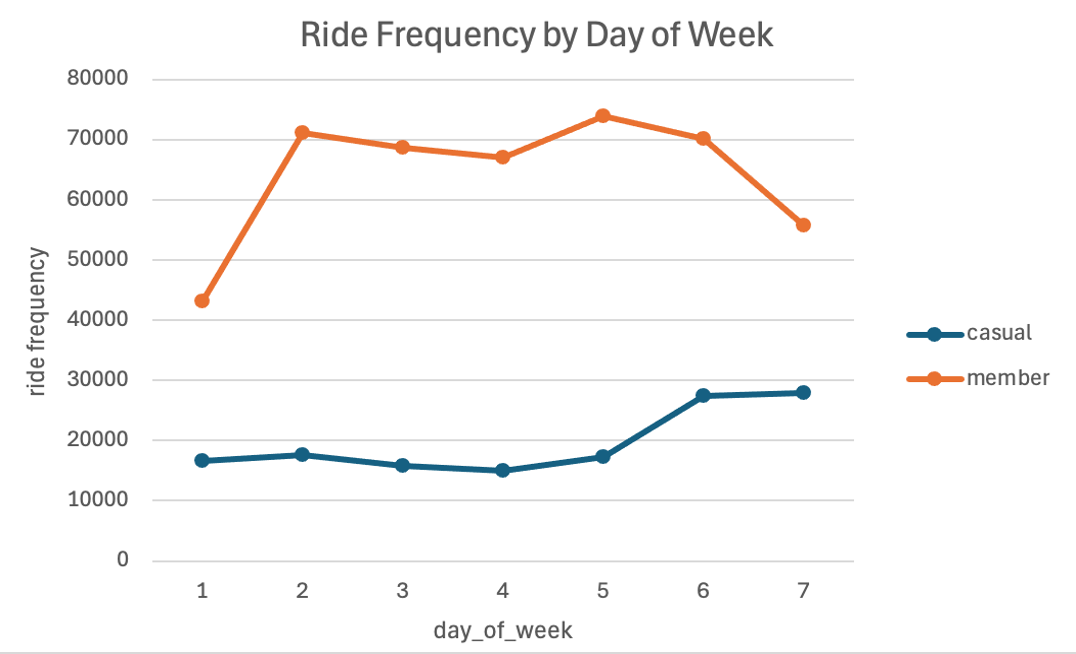


Key findings: Casual riders have longer average ride durations. 
Members ride more frequently on weekdays. 
Casual riders are more active on weekends.

Recommendations: Users who engage in long-distance cycling can enjoy a discount by becoming members.
Offer weekend membership promotions targeting casual riders.
Launch more promotional packages for members.


Act:
I made the entire analysis process and the charts and conclusions into a ppt to show it to my audience and stakeholders.